# Imports, Configuration, and Data Loading

## Import Libraries

In [1]:
# !pip install tensorflow-model-optimization

In [2]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile

import tensorflow as tf
import tf_keras as keras
from tf_keras import layers, models
from tf_keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# !pip install tensorflow-model-optimization
import tensorflow_model_optimization as tfmot

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Reproducibility

In [3]:
os.environ['PYTHONHASHSEED'] = '42'

# Set Deterministic Ops flags for GPU
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Set Global Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configure TensorFlow for Determinism
tf.config.experimental.enable_op_determinism()

print(f"Reproducibility seeds set to: {SEED}")

Reproducibility seeds set to: 42


## Configuration

In [4]:
BASE_DIR = '/content/drive/MyDrive/AI_System_Design/Dataset_V10'
TRAIN_DIR = f'{BASE_DIR}/train'
VAL_DIR   = f'{BASE_DIR}/val'
TEST_DIR  = f'{BASE_DIR}/test'

BATCH_SIZE  = 32
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
IMG_SHAPE   = (IMG_HEIGHT, IMG_WIDTH, 3)
NUM_CLASSES = 10

## Data Loading

In [5]:
print("--- Loading Datasets ---")

train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='int',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

validation_dataset = image_dataset_from_directory(
    VAL_DIR,
    label_mode='int',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

test_dataset = image_dataset_from_directory(
    TEST_DIR,
    label_mode='int',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

class_names = train_dataset.class_names
print(f"Classes found: {class_names}")

--- Loading Datasets ---
Found 912 files belonging to 10 classes.
Found 102 files belonging to 10 classes.
Found 103 files belonging to 10 classes.
Classes found: ['barbell', 'bench-press', 'dumbell', 'kattle-ball', 'leg-press', 'punching-bag', 'roller-abs', 'statis-bicycle', 'step', 'treadmill']


## Helper function

In [6]:
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Training Baseline Models (MobileNetV3 & EfficientNet)

In [7]:
def build_model(model_type):
    inputs = layers.Input(shape=IMG_SHAPE)

    # We support three models to compare Size vs. Accuracy
    if model_type == 'MobileNetV3Large':
        preprocess = keras.applications.mobilenet_v3.preprocess_input
        base = keras.applications.MobileNetV3Large(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
    elif model_type == 'MobileNetV3Small':
        preprocess = keras.applications.mobilenet_v3.preprocess_input
        base = keras.applications.MobileNetV3Small(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
    elif model_type == 'EfficientNetB0':
        preprocess = keras.applications.efficientnet.preprocess_input
        base = keras.applications.EfficientNetB0(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
    else:
        raise ValueError("Unknown model type")

    base.trainable = False # Freeze base

    x = preprocess(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    # Compile Model
    model = models.Model(inputs, outputs, name=model_type)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def evaluate_model(model, dataset, classes):
    print(f"\n--- Evaluating {model.name} ---")

    # Get predictions
    predictions = model.predict(dataset)
    y_pred = np.argmax(predictions, axis=1)

    # Get true labels
    y_true = np.concatenate([y for x, y in dataset], axis=0)

    # Print Classification Report
    print(classification_report(y_true, y_pred, target_names=classes))

    # Plot Matrix
    plot_confusion_matrix(y_true, y_pred, classes, title=f'Confusion Matrix: {model.name}')

## Train MobileNetV3-Large

In [8]:
print("\n=== Training MobileNetV3-Large ===")
# Create the MobileNetV3-Large architecture.
model_large = build_model('MobileNetV3Large')
model_large.summary()


=== Training MobileNetV3-Large ===
12683000/12683000 [==============================] - 0s 0us/step
Model: "MobileNetV3Large"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3large (Function  (None, 7, 7, 960)         2996352   
 al)                                                             
                                                                 
 global_average_pooling2d (  (None, 960)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 960)               0         
                                                                 
 dense (Dense)               (None, 10)                9610      
               

Epoch 1/10
29/29 [==============================] - 150s 4s/step - loss: 1.6799 - accuracy: 0.4846 - val_loss: 0.5288 - val_accuracy: 0.9118
Epoch 2/10
29/29 [==============================] - 4s 113ms/step - loss: 0.3906 - accuracy: 0.9211 - val_loss: 0.2221 - val_accuracy: 0.9510
Epoch 3/10
29/29 [==============================] - 4s 93ms/step - loss: 0.2044 - accuracy: 0.9638 - val_loss: 0.1526 - val_accuracy: 0.9608
Epoch 4/10
29/29 [==============================] - 3s 94ms/step - loss: 0.1190 - accuracy: 0.9868 - val_loss: 0.1261 - val_accuracy: 0.9608
Epoch 5/10
29/29 [==============================] - 4s 97ms/step - loss: 0.0864 - accuracy: 0.9923 - val_loss: 0.1145 - val_accuracy: 0.9608
Epoch 6/10
29/29 [==============================] - 4s 117ms/step - loss: 0.0726 - accuracy: 0.9945 - val_loss: 0.1027 - val_accuracy: 0.9706
Epoch 7/10
29/29 [==============================] - 3s 93ms/step - loss: 0.0544 - accuracy: 0.9956 - val_loss: 0.0939 - val_accuracy: 0.9608
Epoch 8/10


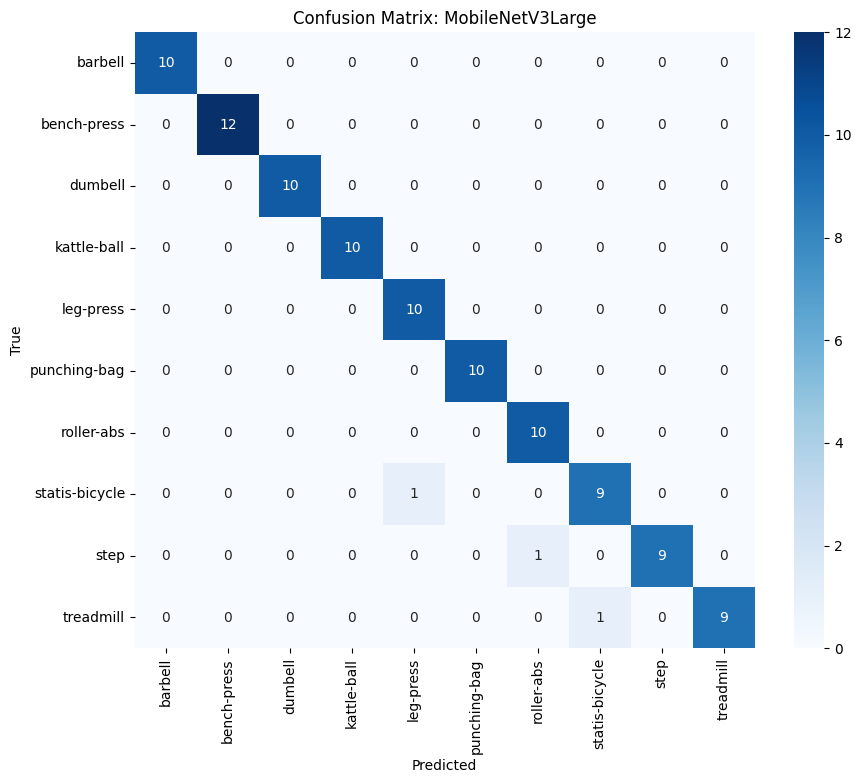

In [9]:
# Train the MobileNetV3-Large Model
history_large = model_large.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

# Save & Evaluate
model_large.save('mobilenetv3_large_baseline.keras')
evaluate_model(model_large, validation_dataset, class_names)

## Train MobileNetV3-Small

In [10]:
print("\n=== Training MobileNetV3-Small ===")
# Create the MobileNetV3-Small architecture.
model_small = build_model('MobileNetV3Small')
model_small.summary()


=== Training MobileNetV3-Small ===
4334752/4334752 [==============================] - 0s 0us/step
Model: "MobileNetV3Small"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3small (Function  (None, 7, 7, 576)         939120    
 al)                                                             
                                                                 
 global_average_pooling2d_1  (None, 576)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_1 (Dropout)         (None, 576)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                5770      
                 

Epoch 1/10
29/29 [==============================] - 9s 134ms/step - loss: 1.9647 - accuracy: 0.3333 - val_loss: 1.1036 - val_accuracy: 0.6961
Epoch 2/10
29/29 [==============================] - 3s 95ms/step - loss: 0.8716 - accuracy: 0.7577 - val_loss: 0.5807 - val_accuracy: 0.8431
Epoch 3/10
29/29 [==============================] - 3s 88ms/step - loss: 0.5314 - accuracy: 0.8717 - val_loss: 0.4070 - val_accuracy: 0.8725
Epoch 4/10
29/29 [==============================] - 3s 88ms/step - loss: 0.3634 - accuracy: 0.9254 - val_loss: 0.3240 - val_accuracy: 0.8824
Epoch 5/10
29/29 [==============================] - 3s 87ms/step - loss: 0.2922 - accuracy: 0.9474 - val_loss: 0.2774 - val_accuracy: 0.9216
Epoch 6/10
29/29 [==============================] - 4s 112ms/step - loss: 0.2298 - accuracy: 0.9594 - val_loss: 0.2500 - val_accuracy: 0.9118
Epoch 7/10
29/29 [==============================] - 3s 86ms/step - loss: 0.1957 - accuracy: 0.9660 - val_loss: 0.2237 - val_accuracy: 0.9314
Epoch 8/10


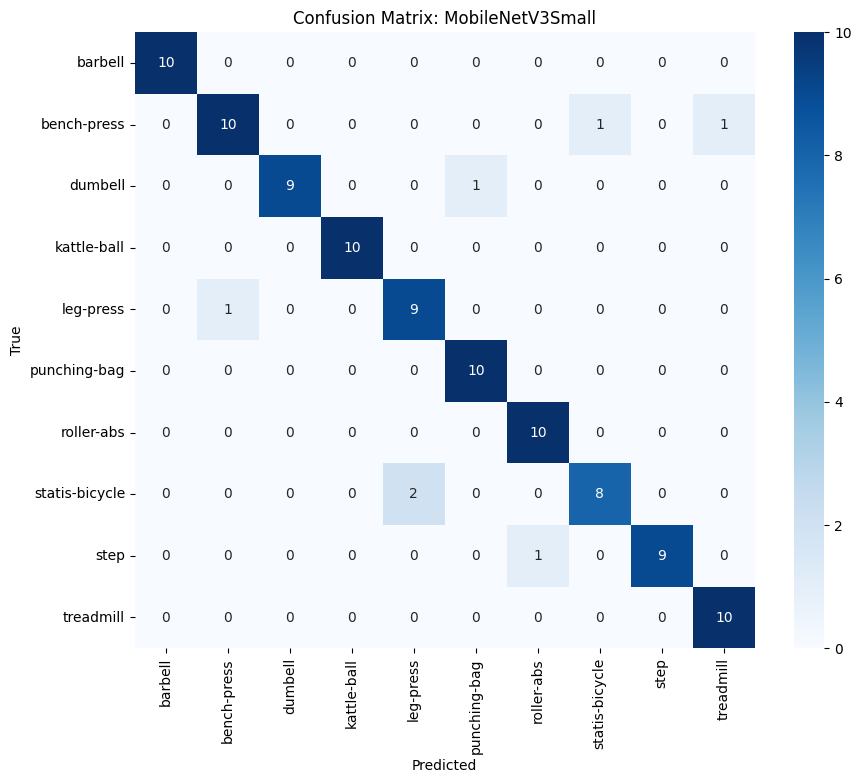

In [11]:
# Train the MobileNetV3-Small Model
history_small = model_small.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

# Save & Evaluate
model_small.save('mobilenetv3_small_baseline.keras')
evaluate_model(model_small, validation_dataset, class_names)

## Train EfficientNet-B0

In [12]:
print("\n=== Training EfficientNet-B0 ===")
# Create the EfficientNet-B0 architecture.
model_eff = build_model('EfficientNetB0')
model_eff.summary()


=== Training EfficientNet-B0 ===
16705208/16705208 [==============================] - 0s 0us/step
Model: "EfficientNetB0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 10)                12810     
                   

Epoch 1/10
29/29 [==============================] - 13s 155ms/step - loss: 1.1604 - accuracy: 0.7401 - val_loss: 0.4848 - val_accuracy: 0.9608
Epoch 2/10
29/29 [==============================] - 4s 100ms/step - loss: 0.3078 - accuracy: 0.9704 - val_loss: 0.2262 - val_accuracy: 0.9902
Epoch 3/10
29/29 [==============================] - 4s 119ms/step - loss: 0.1607 - accuracy: 0.9923 - val_loss: 0.1498 - val_accuracy: 0.9902
Epoch 4/10
29/29 [==============================] - 4s 103ms/step - loss: 0.1042 - accuracy: 0.9923 - val_loss: 0.1200 - val_accuracy: 1.0000
Epoch 5/10
29/29 [==============================] - 4s 101ms/step - loss: 0.0784 - accuracy: 0.9967 - val_loss: 0.0993 - val_accuracy: 1.0000
Epoch 6/10
29/29 [==============================] - 4s 110ms/step - loss: 0.0616 - accuracy: 0.9945 - val_loss: 0.0857 - val_accuracy: 1.0000
Epoch 7/10
29/29 [==============================] - 4s 117ms/step - loss: 0.0505 - accuracy: 0.9989 - val_loss: 0.0756 - val_accuracy: 1.0000
Epoch

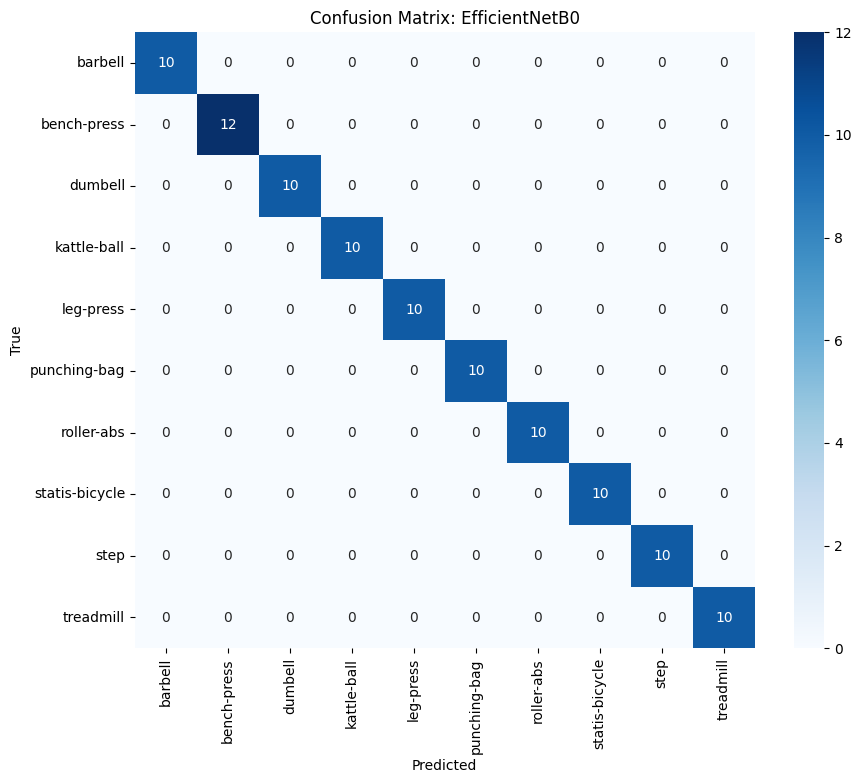

In [13]:
# Train the EfficientNet-B0 Model
history_eff = model_eff.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

# Save & Evaluate
model_eff.save('efficientnet_b0_baseline.keras')
evaluate_model(model_eff, validation_dataset, class_names)

# Knowledge Distillation

In [14]:
## === Knowledge Distillation Experiment ===

# --- Distiller Class ---
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )

            loss = self.alpha * distillation_loss + (1 - self.alpha) * student_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss})

        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": student_loss})

        return results

In [15]:
# Teacher model (EfficientNet-B0)
teacher_model = keras.models.load_model('efficientnet_b0_baseline.keras')
teacher_model.trainable = False

# Student model (MobileNetV3-Small)
student_model_distilled = build_model('MobileNetV3Small')

student_model_distilled.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Configure Distillation
distiller = Distiller(student=student_model_distilled, teacher=teacher_model)

distiller.compile(
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.5,        # 50% Teacher, 50% Ground Truth
    temperature=3
)

In [16]:
# The summary of the Teacher model
print("\n=== Teacher Model Summary ===")
teacher_model.summary()


=== Teacher Model Summary ===
Model: "EfficientNetB0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 10)                12810     
                                                                 
Total params: 4062381

In [17]:
# The summary of the Student model
print("\n=== Distilled Student Model Summary ===")
student_model_distilled.summary()


=== Distilled Student Model Summary ===
Model: "MobileNetV3Small"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3small (Function  (None, 7, 7, 576)         939120    
 al)                                                             
                                                                 
 global_average_pooling2d_3  (None, 576)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_3 (Dropout)         (None, 576)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                5770      
                                                                 
Total par

--- Starting Distillation Training ---
Epoch 1/20
29/29 [==============================] - 12s 135ms/step - accuracy: 0.3783 - loss: 0.8678 - val_accuracy: 0.7255 - val_loss: 1.0592
Epoch 2/20
29/29 [==============================] - 5s 134ms/step - accuracy: 0.7917 - loss: 0.3962 - val_accuracy: 0.8725 - val_loss: 0.7965
Epoch 3/20
29/29 [==============================] - 4s 109ms/step - accuracy: 0.9013 - loss: 0.2328 - val_accuracy: 0.9216 - val_loss: 0.4989
Epoch 4/20
29/29 [==============================] - 4s 105ms/step - accuracy: 0.9342 - loss: 0.1715 - val_accuracy: 0.9118 - val_loss: 0.4700
Epoch 5/20
29/29 [==============================] - 4s 113ms/step - accuracy: 0.9518 - loss: 0.1343 - val_accuracy: 0.9216 - val_loss: 0.3690
Epoch 6/20
29/29 [==============================] - 4s 106ms/step - accuracy: 0.9572 - loss: 0.1077 - val_accuracy: 0.9216 - val_loss: 0.2743
Epoch 7/20
29/29 [==============================] - 4s 101ms/step - accuracy: 0.9748 - loss: 0.0923 - val_ac

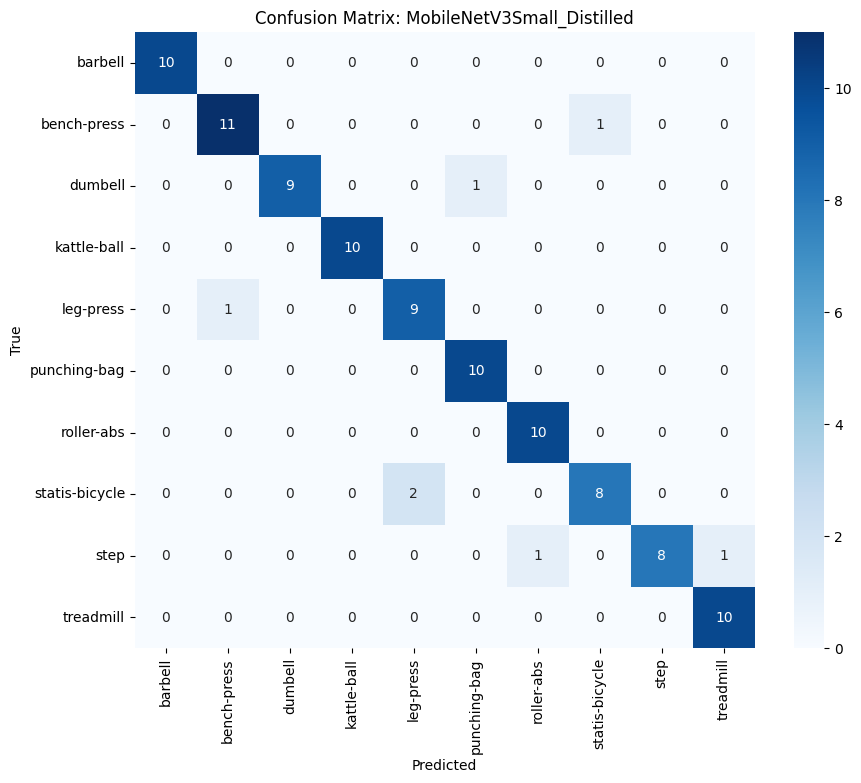

In [18]:
# Distillation Training
print("--- Starting Distillation Training ---")
history_distill = distiller.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset
)

# Save & Evaluate
# We save the inner model which is the student
student_model_distilled.save('mobilenetv3_small_distilled.keras')
student_model_distilled._name = "MobileNetV3Small_Distilled" # Rename for plot title
evaluate_model(student_model_distilled, validation_dataset, class_names)

## Model Choice

We selected MobileNetV3-Large because it offers the perfect balance between high accuracy and efficient size for a mobile application.

**Performance Comparison**

While MobileNetV3-Small was the lightest model (3.6 MB), it suffered from the lowest accuracy (92%).

EfficientNet-B0 had the highest accuracy (99%), it was the heaviest model (15.5 MB).

MobileNetV3-Large proved to be the best choice, achieving 97% accuracy with a manageable file size (11.5 MB).


Now Let's try to Prune it and then quantize it to make it smaller and save accuracy and results as possible

# Pruning (On MobileNetV3-Large)

In [19]:
print("\n=== Pruning MobileNetV3-Large ===")

# Load Baseline
baseline_model = keras.models.load_model('mobilenetv3_large_baseline.keras')

# Setup Pruning
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

EPOCHS_PRUNING = 10
num_train_images = tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE
end_step = np.ceil(num_train_images / BATCH_SIZE).astype(np.int32) * EPOCHS_PRUNING

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.00,
        final_sparsity=0.50,
        begin_step=0,
        end_step=end_step
    )
}

def apply_pruning_to_layers(layer):
    if isinstance(layer, (layers.Dense, layers.Conv2D)):
        return prune_low_magnitude(layer, **pruning_params)
    return layer

model_for_pruning = models.clone_model(
    baseline_model,
    clone_function=apply_pruning_to_layers,
)

model_for_pruning.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Fine-tune
logdir = tempfile.mkdtemp()
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
]

print("Start pruning fine-tuning...")
history_pruned = model_for_pruning.fit(
    train_dataset,
    epochs=EPOCHS_PRUNING,
    validation_data=validation_dataset,
    callbacks=callbacks
)

# 4. Strip & Save
model_pruned_stripped = tfmot.sparsity.keras.strip_pruning(model_for_pruning)
model_pruned_stripped.save('mobilenetv3_large_pruned.keras')
print("Saved: mobilenetv3_large_pruned.keras")


=== Pruning MobileNetV3-Large ===
Start pruning fine-tuning...
Epoch 1/10
29/29 [==============================] - 10s 143ms/step - loss: 0.0285 - accuracy: 0.9989 - val_loss: 0.0707 - val_accuracy: 0.9608
Epoch 2/10
29/29 [==============================] - 4s 106ms/step - loss: 0.0178 - accuracy: 1.0000 - val_loss: 0.0616 - val_accuracy: 0.9804
Epoch 3/10
29/29 [==============================] - 4s 118ms/step - loss: 0.0097 - accuracy: 1.0000 - val_loss: 0.0599 - val_accuracy: 0.9706
Epoch 4/10
29/29 [==============================] - 8s 242ms/step - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.0477 - val_accuracy: 0.9902
Epoch 5/10
29/29 [==============================] - 6s 156ms/step - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.0606 - val_accuracy: 0.9804
Epoch 6/10
29/29 [==============================] - 4s 117ms/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.0585 - val_accuracy: 0.9804
Epoch 7/10
29/29 [==============================] - 3s 92ms/step - loss: 0.0047 - a

In [20]:
print("\n=== Pruned Model Summary (Stripped) ===")
model_pruned_stripped.summary()


=== Pruned Model Summary (Stripped) ===
Model: "MobileNetV3Large"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3large (Function  (None, 7, 7, 960)         2996352   
 al)                                                             
                                                                 
 global_average_pooling2d (  (None, 960)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 960)               0         
                                                                 
 dense (Dense)               (None, 10)                9610      
                                                                 
Total par

In [21]:
def print_model_sparsity(model):
    all_weights = []
    for layer in model.layers:
        if isinstance(layer, (tf.keras.layers.Dense, tf.keras.layers.Conv2D)):
            w = layer.get_weights()[0] # Get the weights (not biases)
            all_weights.append(w.flatten())

    all_weights = np.concatenate(all_weights)
    zero_weights = np.count_nonzero(all_weights == 0)
    total_weights = all_weights.size

    print(f"\n=== Pruning Verification ===")
    print(f"Total Weights: {total_weights}")
    print(f"Zero Weights:  {zero_weights}")
    print(f"Sparsity:      {zero_weights / total_weights:.2%}")


print_model_sparsity(model_pruned_stripped)


=== Pruning Verification ===
Total Weights: 9600
Zero Weights:  4657
Sparsity:      48.51%



--- Evaluating MobileNetV3Large ---
4/4 [==============================] - 1s 69ms/step
                precision    recall  f1-score   support

       barbell       1.00      1.00      1.00        10
   bench-press       0.92      1.00      0.96        12
       dumbell       1.00      1.00      1.00        10
   kattle-ball       1.00      1.00      1.00        10
     leg-press       0.90      0.90      0.90        10
  punching-bag       1.00      1.00      1.00        10
    roller-abs       0.91      1.00      0.95        10
statis-bicycle       1.00      0.90      0.95        10
          step       1.00      0.80      0.89        10
     treadmill       0.91      1.00      0.95        10

      accuracy                           0.96       102
     macro avg       0.96      0.96      0.96       102
  weighted avg       0.96      0.96      0.96       102



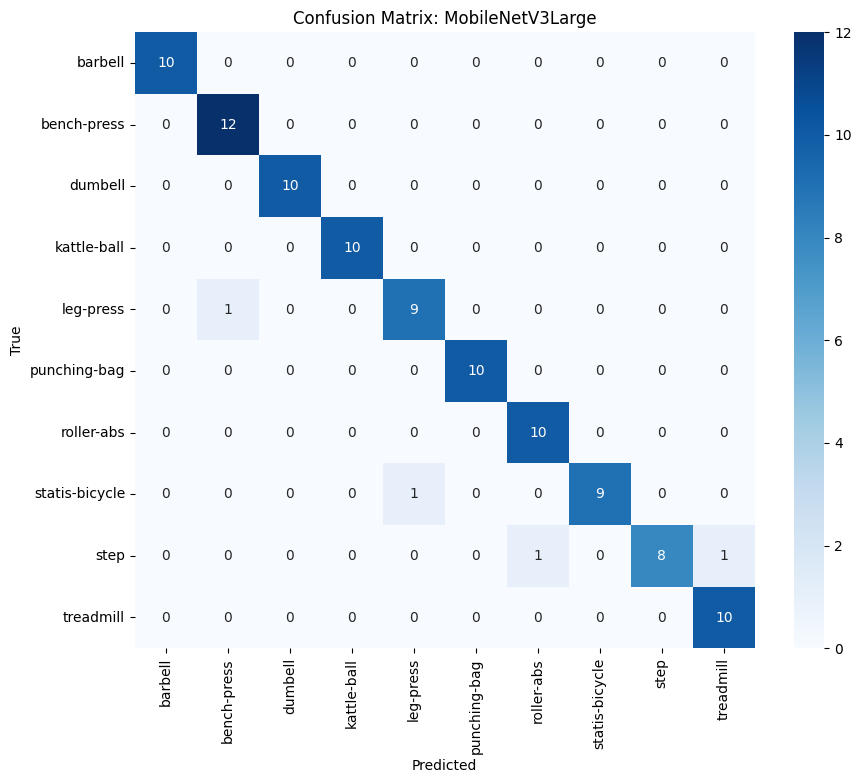

In [22]:
evaluate_model(model_pruned_stripped, validation_dataset, class_names)

# Quantization & TFLite Conversion (on pruned mobilenetv3-large)

In [23]:
#  Quantization & TFLite Conversion
print("\n=== Quantizing & Converting to TFLite ===")

# Load the pruned model
pruned_model = keras.models.load_model('mobilenetv3_large_pruned.keras')

# --- Convert to Float32 TFLite (No Quantization) ---
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
tflite_float32 = converter.convert()

with open('model_pruned_float32.tflite', 'wb') as f:
    f.write(tflite_float32)
print("Generated: model_pruned_float32.tflite")

# --- Convert to Float16 TFLite ---
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_float16 = converter.convert()

with open('model_pruned_float16.tflite', 'wb') as f:
    f.write(tflite_float16)
print("Generated: model_pruned_float16.tflite")

# --- Convert to Int8 (Dynamic Range Quantization) ---
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_int8 = converter.convert()

with open('model_pruned_int8_dynamic.tflite', 'wb') as f:
    f.write(tflite_int8)
print("Generated: model_pruned_int8_dynamic.tflite")


=== Quantizing & Converting to TFLite ===
Generated: model_pruned_float32.tflite
Generated: model_pruned_float16.tflite
Generated: model_pruned_int8_dynamic.tflite


In [24]:
# Final Comparison & Analysis

def get_file_size(file_path):
    return os.path.getsize(file_path) / (1024 * 1024)

print("\n=== Final Model Sizes (MB) ===")
print(f"Original Keras Model:     {get_file_size('mobilenetv3_large_baseline.keras'):.2f} MB")
print(f"Pruned Keras Model:       {get_file_size('mobilenetv3_large_pruned.keras'):.2f} MB")
print("-" * 50)
print(f"TFLite Float32:           {get_file_size('model_pruned_float32.tflite'):.2f} MB")
print(f"TFLite Float16:           {get_file_size('model_pruned_float16.tflite'):.2f} MB")
print(f"TFLite Int8 (Dynamic):    {get_file_size('model_pruned_int8_dynamic.tflite'):.2f} MB")



=== Final Model Sizes (MB) ===
Original Keras Model:     12.28 MB
Pruned Keras Model:       12.20 MB
--------------------------------------------------
TFLite Float32:           11.37 MB
TFLite Float16:           5.72 MB
TFLite Int8 (Dynamic):    3.13 MB


In [25]:
def evaluate_tflite(model_path, dataset, class_names):
    print(f"\n{'='*40}")
    print(f"Evaluating: {os.path.basename(model_path)}")
    print(f"{'='*40}")

    # Load Interpreter
    interpreter = tf.lite.Interpreter(
        model_path=model_path,
        experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    )
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]['index']
    output_index = output_details[0]['index']

    # Quantization setup
    input_scale, input_zero_point = input_details[0]['quantization']
    model_expects_int8 = (input_details[0]['dtype'] == np.int8) or (input_details[0]['dtype'] == np.uint8)

    y_true = []
    y_pred = []
    inference_times = []

    print("Running inference... (This might take a moment)")

    for batch_images, batch_labels in dataset:
        for i in range(len(batch_images)):
            # Preprocess
            input_data = np.expand_dims(batch_images[i], axis=0).astype(np.float32)

            # Handle Int8 conversion if needed
            if model_expects_int8:
                input_data = input_data / input_scale + input_zero_point
                input_data = input_data.astype(input_details[0]['dtype'])

            # Inference
            start_time = time.time()
            interpreter.set_tensor(input_index, input_data)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_index)
            end_time = time.time()

            inference_times.append(end_time - start_time)

            # Prediction
            pred_label = np.argmax(output_data)
            y_pred.append(pred_label)
            y_true.append(batch_labels[i])

    # --- Metrics Calculation ---
    acc = accuracy_score(y_true, y_pred)
    avg_time = np.mean(inference_times) * 1000 # ms
    size_mb = os.path.getsize(model_path) / (1024 * 1024)

    # --- Visualizations ---
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {os.path.basename(model_path)}')
    plt.show()

    # --- FINAL RESULT PRINT FOR THIS MODEL ---
    print("-" * 40)
    print(f"FINAL RESULTS: {os.path.basename(model_path)}")
    print("-" * 40)
    print(f"SIZE:     {size_mb:.2f} MB")
    print(f"ACCURACY: {acc:.2%}")
    print(f"LATENCY:  {avg_time:.2f} ms")
    print("-" * 40)


Evaluating: model_pruned_float32.tflite
Running inference... (This might take a moment)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



--- Classification Report ---
                precision    recall  f1-score   support

       barbell       1.00      1.00      1.00        10
   bench-press       0.92      1.00      0.96        12
       dumbell       1.00      1.00      1.00        10
   kattle-ball       1.00      1.00      1.00        10
     leg-press       0.90      0.90      0.90        10
  punching-bag       1.00      1.00      1.00        10
    roller-abs       0.91      1.00      0.95        10
statis-bicycle       1.00      0.90      0.95        10
          step       1.00      0.80      0.89        10
     treadmill       0.91      1.00      0.95        10

      accuracy                           0.96       102
     macro avg       0.96      0.96      0.96       102
  weighted avg       0.96      0.96      0.96       102



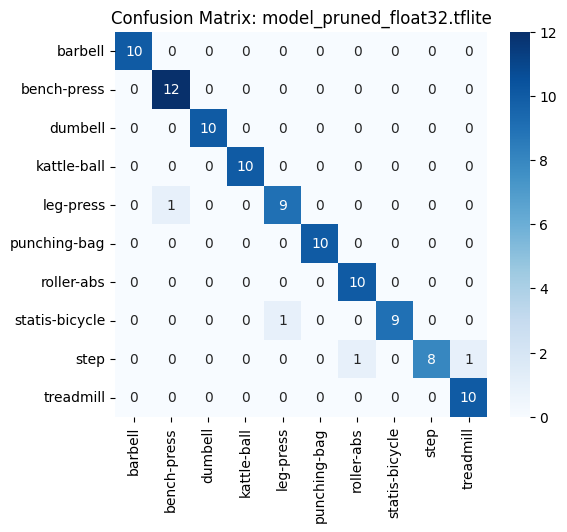

----------------------------------------
FINAL RESULTS: model_pruned_float32.tflite
----------------------------------------
SIZE:     11.37 MB
ACCURACY: 96.08%
LATENCY:  19.63 ms
----------------------------------------


In [26]:
model_file = 'model_pruned_float32.tflite'

if os.path.exists(model_file):
    evaluate_tflite(model_file, validation_dataset, class_names)
else:
    print(f"Error: {model_file} not found.")


Evaluating: model_pruned_float16.tflite
Running inference... (This might take a moment)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



--- Classification Report ---
                precision    recall  f1-score   support

       barbell       1.00      1.00      1.00        10
   bench-press       0.92      1.00      0.96        12
       dumbell       1.00      1.00      1.00        10
   kattle-ball       1.00      1.00      1.00        10
     leg-press       0.90      0.90      0.90        10
  punching-bag       1.00      1.00      1.00        10
    roller-abs       0.91      1.00      0.95        10
statis-bicycle       1.00      0.90      0.95        10
          step       1.00      0.80      0.89        10
     treadmill       0.91      1.00      0.95        10

      accuracy                           0.96       102
     macro avg       0.96      0.96      0.96       102
  weighted avg       0.96      0.96      0.96       102



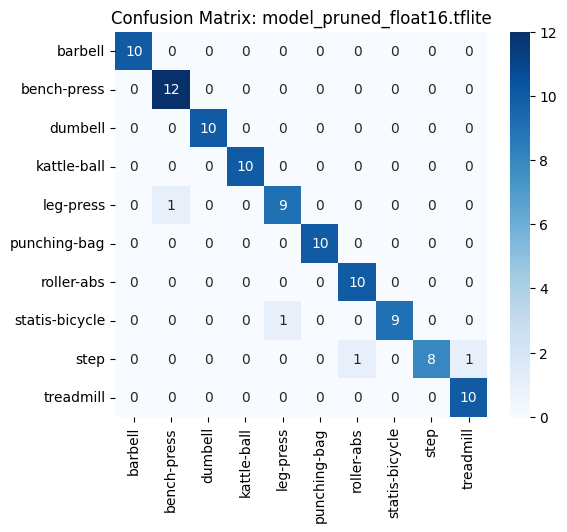

----------------------------------------
FINAL RESULTS: model_pruned_float16.tflite
----------------------------------------
SIZE:     5.72 MB
ACCURACY: 96.08%
LATENCY:  19.67 ms
----------------------------------------


In [27]:
model_file = 'model_pruned_float16.tflite'

if os.path.exists(model_file):
    evaluate_tflite(model_file, validation_dataset, class_names)
else:
    print(f"Error: {model_file} not found.")


Evaluating: model_pruned_int8_dynamic.tflite
Running inference... (This might take a moment)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



--- Classification Report ---
                precision    recall  f1-score   support

       barbell       1.00      1.00      1.00        10
   bench-press       0.92      1.00      0.96        12
       dumbell       1.00      1.00      1.00        10
   kattle-ball       1.00      1.00      1.00        10
     leg-press       0.90      0.90      0.90        10
  punching-bag       1.00      1.00      1.00        10
    roller-abs       0.91      1.00      0.95        10
statis-bicycle       1.00      0.90      0.95        10
          step       1.00      0.80      0.89        10
     treadmill       0.91      1.00      0.95        10

      accuracy                           0.96       102
     macro avg       0.96      0.96      0.96       102
  weighted avg       0.96      0.96      0.96       102



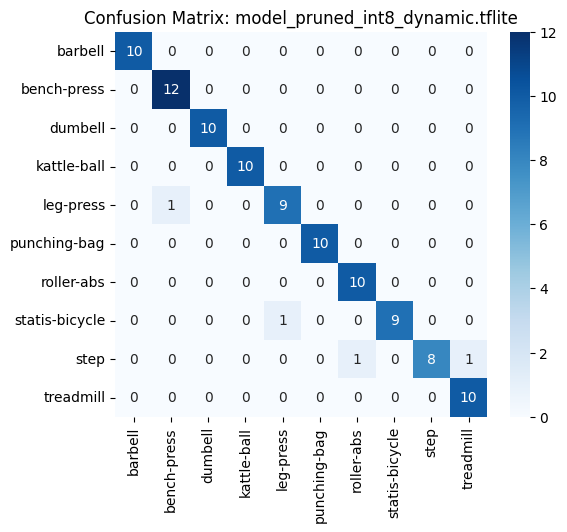

----------------------------------------
FINAL RESULTS: model_pruned_int8_dynamic.tflite
----------------------------------------
SIZE:     3.13 MB
ACCURACY: 96.08%
LATENCY:  19.81 ms
----------------------------------------


In [28]:
model_file = 'model_pruned_int8_dynamic.tflite'

if os.path.exists(model_file):
    evaluate_tflite(model_file, validation_dataset, class_names)
else:
    print(f"Error: {model_file} not found.")

In [30]:
print("\n=== Converting to Full Integer TFLite (Standard Int8) ===")

# 1. Define Representative Dataset Generator for the max and min
def representative_data_gen():
    # Take 100 batches from validation set
    for input_batch, _ in validation_dataset.take(100):
        for i in range(len(input_batch)):

            yield [np.expand_dims(input_batch[i], axis=0).astype(np.float32)]


converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_full_int8_model = converter.convert()

with open('model_pruned_full_int8.tflite', 'wb') as f:
    f.write(tflite_full_int8_model)

print("Generated: model_pruned_full_int8.tflite")


=== Converting to Full Integer TFLite (Standard Int8) ===


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Generated: model_pruned_full_int8.tflite



Evaluating: model_pruned_full_int8.tflite
Running inference... (This might take a moment)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



--- Classification Report ---
                precision    recall  f1-score   support

       barbell       1.00      1.00      1.00        10
   bench-press       1.00      0.75      0.86        12
       dumbell       0.91      1.00      0.95        10
   kattle-ball       1.00      0.80      0.89        10
     leg-press       0.83      1.00      0.91        10
  punching-bag       0.59      1.00      0.74        10
    roller-abs       0.88      0.70      0.78        10
statis-bicycle       1.00      0.90      0.95        10
          step       1.00      0.80      0.89        10
     treadmill       0.80      0.80      0.80        10

      accuracy                           0.87       102
     macro avg       0.90      0.88      0.88       102
  weighted avg       0.90      0.87      0.88       102



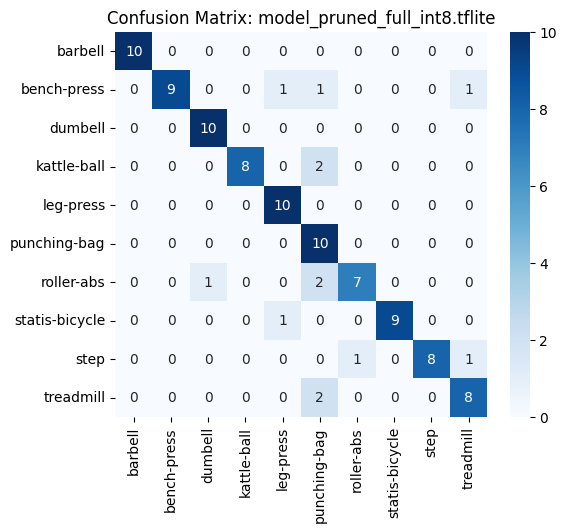

----------------------------------------
FINAL RESULTS: model_pruned_full_int8.tflite
----------------------------------------
SIZE:     3.33 MB
ACCURACY: 87.25%
LATENCY:  85.42 ms
----------------------------------------


In [31]:
model_file = 'model_pruned_full_int8.tflite'

if os.path.exists(model_file):
    evaluate_tflite(model_file, validation_dataset, class_names)
else:
    print(f"Error: {model_file} not found.")